# 23)
First i implement a simulation of the stock price, and plot N=100 paths of the stock price. Note that we can derive the brownian motion from G. If we do not use this specific brownian motion, we wont get the correct variance for the control variate.

$$\prod \left( e^{B(i/p)} \right)^{1/p} = exp(\frac{1}{p}\sum_i (p-i+1)Y_i$$
Implies that
$$\sum_{i}^p B(i/p) = \sum_{i}^p \sum_{j = 1}^i Y_j =  \sum_i^p (p-i+1)Y_i $$

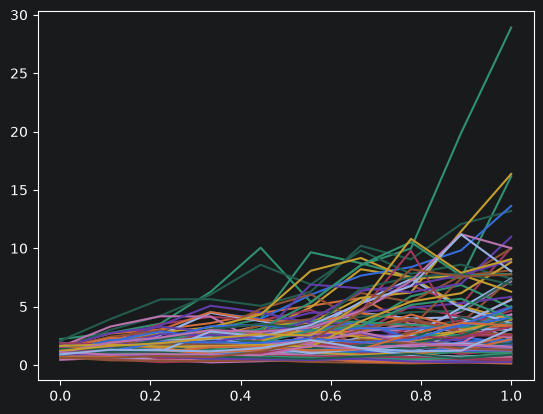

In [13]:
import numpy as np
import matplotlib.pyplot as plt
# Risk free interest
r = 1
# Variance
sigma = 1
# Starting stock price
s0 = 1
K = 3
# Time horizon
T = 1
# Time steps
p = 10

def simulate_stock(T, p, s0):

    timesteps = np.linspace(0, T, p)

    # Y_i from the task
    Y = np.random.normal(
        loc=1/p,
        scale=np.sqrt(1/p),
        size=p
    )

    # Brownian/path values
    B = np.cumsum(Y)

    # Stock prices
    stock = s0 * np.exp(B)

    # Arithmetic average
    stock_bar = np.mean(stock)

    return stock, stock_bar, B, timesteps


N = 100
for i in range(N):
    S,_,_, timesteps = simulate_stock(T, p, s0)
    plt.plot(timesteps, S)
plt.show()


Now we can compute the price of an Asian Knock-in option by using crude Monte Carlo.

In [14]:
N = 10000

def option_payoff(s0, K, T, p):

    s, s_bar, B, _ = simulate_stock(T, p, s0)
    Y = max(s_bar - K, 0)

    return Y, B, s_bar

def simulate_expected_payoff_crude(T, K, s0, N, p):

    payoffs = np.array([option_payoff(s0, K, T, p)[0] for _ in range(N)])
    expected = np.mean(payoffs)
    standard_deviation = np.std(payoffs)

    return expected, standard_deviation

simulate_expected_payoff_crude(T, K, s0, N, p)

(np.float64(0.5041200605819087), np.float64(1.486125168818635))

We now introduce a control variable $Z = max(G-K,0)$, where $G = (\prod_{i=1}^p exp(B(i/p)))^{1/p}$. We can derive the expected value of Z analytically using task 21, and use this to reduce the variance of our estimate of the expected payoff.
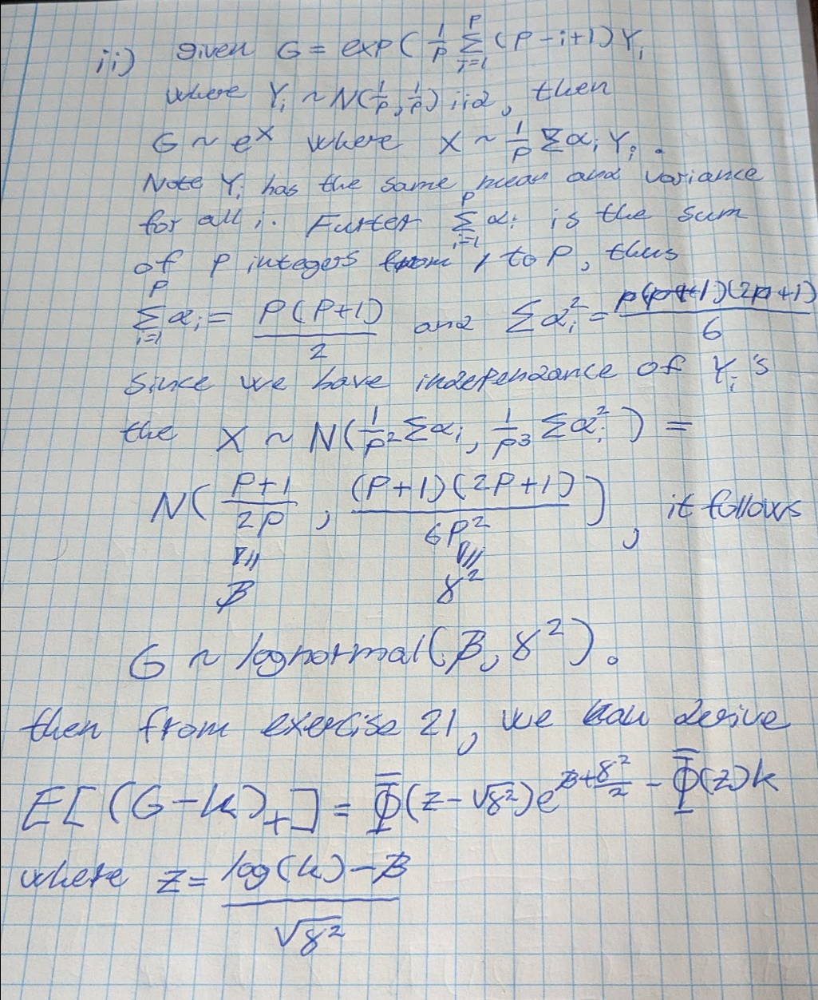
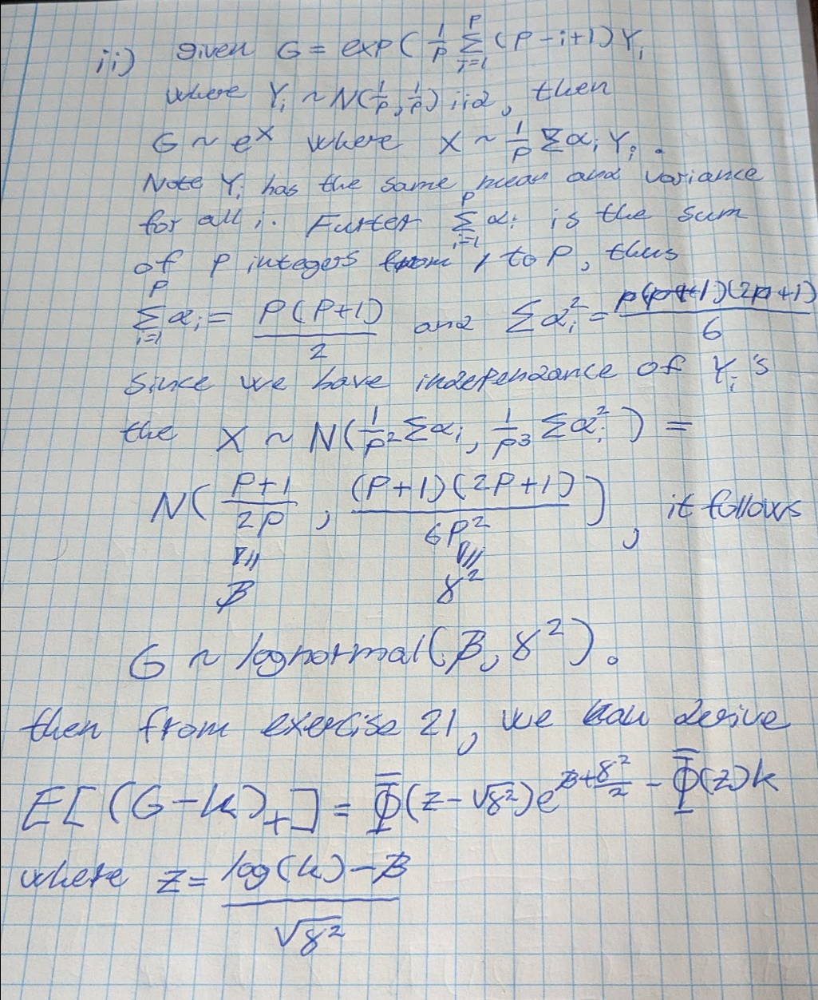

In [15]:
def control_g(B , p, K):
    G = s0*np.prod(np.exp(B))**(1/p)
    return max(G - K, 0)

def expectation_of_control_g(p, K):
    # Derived on paper, using results from task 21
    from scipy.stats import norm
    # Analytical mean
    beta = (p+1) / (2*p)

    # Analytical variance
    gamma_squared = (p+1)*(2*p + 1) / (6*p**2)
    gamma = np.sqrt(gamma_squared)

    z = (np.log(K) - beta) / gamma
    # Note that the tail cdf is phi(-x) = 1 - phi(x)
    # Which is not implied by the task.
    E = norm.cdf(-(z-gamma))
    E *= np.exp(beta + 0.5*gamma_squared)
    E -= K * norm.cdf(-z)
    return E

def compute_optimal_coefficients(Y, Z):
    """
    Compute the optimal coefficients for control variates.
    Y = Target
    Z = Control Variate(s)
    """
    YZ = np.vstack([Y,Z])
    # np.cov, computes the covariance of all each row (variable)
    # S0 we have to extract the according matrices and vectors
    C = np.cov(YZ)
    cov_YZ = C[0, 1:]
    cov_z = C[1:, 1:]
    cov_z_inv = np.linalg.inv(cov_z)

    beta_opt = cov_YZ @ cov_z_inv
    return beta_opt

def simulate_expected_payoff_control_g(T, K, s0, N, p):

    # Expected value of Z
    l_H = expectation_of_control_g(p, K)


    # Y
    simulations = [option_payoff(s0, K, T, p)[0:2] for _ in range(N)]
    payoffs, brownian = zip(*simulations)

    # Control Z, from brownian motion that defines Y
    Z = np.array([control_g(brownian[i], p, K) for i in range(N)])


    beta_opt = compute_optimal_coefficients(payoffs, Z)
    print(beta_opt)

    # Y_tilde ( If we find beta)
    Y_tilde = payoffs - beta_opt*(Z - l_H)

    # Estimate of the expected value
    l = np.mean(Y_tilde)
    standard_deviation = np.std(Y_tilde)

    return l, standard_deviation

simulate_expected_payoff_control_g(T, K, s0, N, p)

[1.73414948]


(np.float64(0.5424695189028064), np.float64(0.452675664580758))

## iii)
We now instead use $\bar S$ as a control variable, and compute the expected value of $\bar S$ analytically.
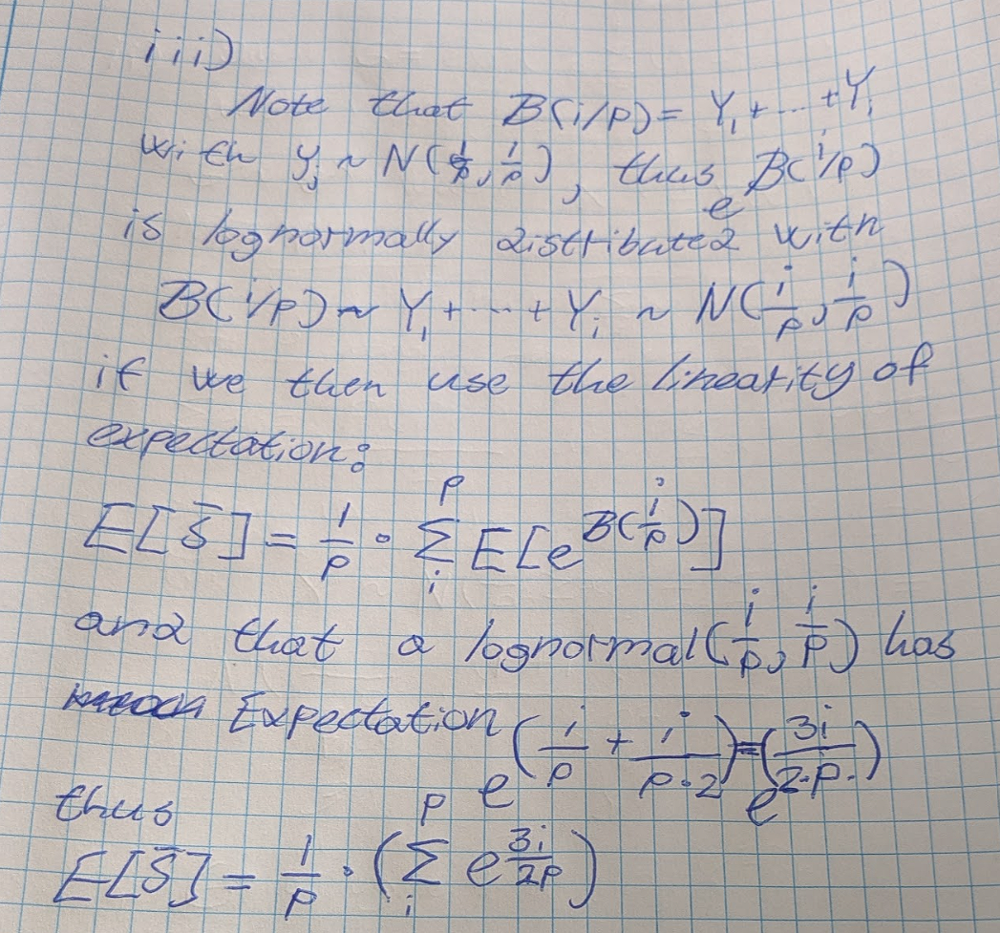

In [17]:
def expectation_of_control_s(p):
    # Derived on paper
    E = np.sum(
       s0 * np.exp(
            np.array([3*i / (2*p) for i in range(1,p + 1)])
        )
    )
    E /= p
    return E


def simulate_expected_payoff_control_s(T, K, s0, N, p):

    # Expected value of Z
    l_H = expectation_of_control_s(p)

    # Y
    simulations = [option_payoff(s0, K, T, p) for _ in range(N)]
    payoffs, brownian, s_bar = zip(*simulations)

    # Control Z, from brownian motion that defines Y
    # This is S_bar
    Z = np.array(s_bar)
    beta_opt = compute_optimal_coefficients(payoffs, Z)
    print("Optimal beta: ", beta_opt)
    # Y_tilde
    Y_tilde = payoffs - beta_opt*(Z - l_H)

    # Estimate of the expected value
    l = np.mean(Y_tilde)
    standard_deviation = np.std(Y_tilde)

    return l, standard_deviation

simulate_expected_payoff_control_s(T, K, s0, N, p)

Optimal beta:  [0.72600485]


(np.float64(0.5466406118721797), np.float64(0.5967632230869524))